In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import exp,log
from dotenv import load_dotenv

load_dotenv()
data_path = str(os.getenv("Data_path"))

df = pd.read_csv(data_path)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   str    
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   str    
 10  alcohol_consumption  1000 non-null   str    
 11  physical_activity    1000 non-null   str    
 12  family_history       1000 non-null   str    
 13  disease              1000 non-null   str    
dtypes: float64(1), int64(7), str(6)
memory usage: 109.5 KB
None


In [3]:
df['gender'] = df['gender'].map({'Male':1,'Female':0})
df['smoking'] = df['smoking'].map({'Yes':1,'No':0})
df['alcohol_consumption'] = df['alcohol_consumption'].map({'Yes':1,'No':0})
df['disease'] = df['disease'].map({'Yes':1,'No':0})

print(df.head(5))

   patient_id  age  gender  glucose_mg_dl  cholesterol_mg_dl  systolic_bp  \
0           1   32       1            101                235          152   
1           2   31       1            124                191          134   
2           3   45       1             57                141          114   
3           4   75       0             69                268          120   
4           5   53       1            107                163          131   

   diastolic_bp   bmi  heart_rate  smoking  alcohol_consumption  \
0            79  28.5          73        0                    1   
1            77  33.9          71        0                    1   
2            71  27.2          79        1                    1   
3            82  21.5          61        1                    1   
4            75  23.3          73        1                    0   

  physical_activity family_history  disease  
0               Low            Yes        1  
1               Low            Yes        

{'whiskers': [<matplotlib.lines.Line2D at 0x7f0bb24be270>,
 'caps': [<matplotlib.lines.Line2D at 0x7f0bb24be510>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f0bb24be120>,
 'medians': [<matplotlib.lines.Line2D at 0x7f0bb24be7b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f0bb24be900>,
 'means': []}

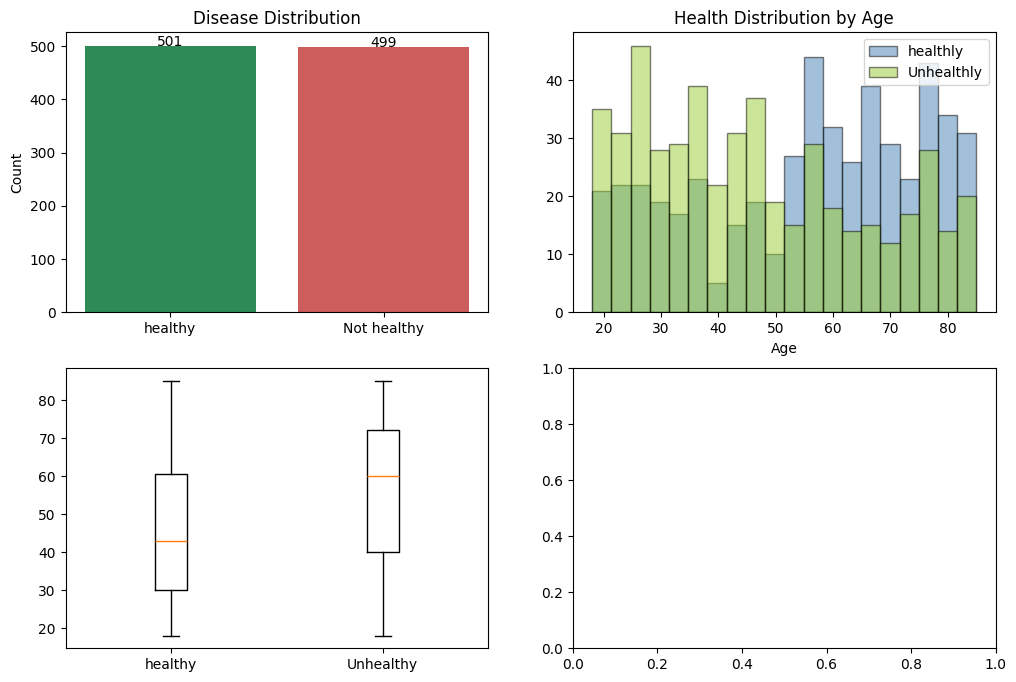

In [4]:
fig,ax = plt.subplots(ncols=2,nrows=2,figsize=(12,8))
ishealthy = (df['disease']==1).sum()
nothealthy = (df['disease']==0).sum()

#bar
health = ax[0,0]
bars= health.bar(["healthy","Not healthy"],[ishealthy,nothealthy],color =['seagreen','indianred'])

for b in bars:
    height =  b.get_height()
    health.annotate(f"{height}",xy=(b.get_x()+b.get_width()/2,height),ha='center')

health.set_title("Disease Distribution")
health.set_ylabel("Count")

#histogram

ax[0,1].hist(df.loc[df['disease']==1,'age'],bins=20,color='steelblue',ec='black',label='healthly',alpha=0.5)
ax[0,1].hist(df.loc[df['disease']==0,'age'],bins=20,color='yellowgreen',ec='black',label='Unhealthly',alpha=0.5)
ax[0,1].legend()
ax[0,1].set_title("Health Distribution by Age")
ax[0,1].set_xlabel("Age")

#Box

Box = ax[1,0]
healthy = df.loc[df['disease']==0, 'age']
not_healthy = df.loc[df['disease']==1, 'age']
Box.boxplot([healthy,not_healthy],tick_labels=['healthy','Unhealthy'])


In [5]:
df = pd.get_dummies(df,columns=['physical_activity'],drop_first=True,dtype=int)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   gender                    1000 non-null   int64  
 3   glucose_mg_dl             1000 non-null   int64  
 4   cholesterol_mg_dl         1000 non-null   int64  
 5   systolic_bp               1000 non-null   int64  
 6   diastolic_bp              1000 non-null   int64  
 7   bmi                       1000 non-null   float64
 8   heart_rate                1000 non-null   int64  
 9   smoking                   1000 non-null   int64  
 10  alcohol_consumption       1000 non-null   int64  
 11  family_history            1000 non-null   str    
 12  disease                   1000 non-null   int64  
 13  physical_activity_Low     1000 non-null   int64  
 14  physical_activity_Me

In [6]:
df['family_history'] = df['family_history'].map({'Yes':1,'No':0})

print(df.head(2).to_string())

   patient_id  age  gender  glucose_mg_dl  cholesterol_mg_dl  systolic_bp  diastolic_bp   bmi  heart_rate  smoking  alcohol_consumption  family_history  disease  physical_activity_Low  physical_activity_Medium
0           1   32       1            101                235          152            79  28.5          73        0                    1               1        1                      1                         0
1           2   31       1            124                191          134            77  33.9          71        0                    1               1        1                      1                         0


In [7]:
print(df.shape)
#print(df.isnull().sum)
print(df.info())

(1000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   gender                    1000 non-null   int64  
 3   glucose_mg_dl             1000 non-null   int64  
 4   cholesterol_mg_dl         1000 non-null   int64  
 5   systolic_bp               1000 non-null   int64  
 6   diastolic_bp              1000 non-null   int64  
 7   bmi                       1000 non-null   float64
 8   heart_rate                1000 non-null   int64  
 9   smoking                   1000 non-null   int64  
 10  alcohol_consumption       1000 non-null   int64  
 11  family_history            1000 non-null   int64  
 12  disease                   1000 non-null   int64  
 13  physical_activity_Low     1000 non-null   int64  
 14  physical_

In [8]:
y= df['disease'].values

df.drop(columns=['disease','patient_id'],inplace=True)

x= df.values

print(y,x)

[1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 1 0
 1 0 1 0 1 1 0 0 1 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 0 1 0 1 0 0 0 0 1 1 0 1 0
 0 1 0 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 1
 1 0 1 0 1 1 1 0 1 1 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1 1
 1 1 1 1 1 0 1 1 0 0 0 1 1 0 1 0 0 0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 1 0 1 1 0
 1 1 1 0 1 0 1 1 1 1 0 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 1 0 1 0 1 0 1 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1
 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0
 0 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0
 1 0 0 0 0 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 1 0 1
 1 0 0 0 0 0 0 1 1 1 0 1 

In [9]:
np.random.seed(69)

idx = np.random.permutation(len(x))
split = int(0.8*len(x))

x_train,x_test = x[idx[:split]],x[idx[split:]]
y_train,y_test = y[idx[:split]],y[idx[split:]]

print(x_train.shape)
print(y_train.shape)
print(df.info())

(800, 13)
(800,)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1000 non-null   int64  
 1   gender                    1000 non-null   int64  
 2   glucose_mg_dl             1000 non-null   int64  
 3   cholesterol_mg_dl         1000 non-null   int64  
 4   systolic_bp               1000 non-null   int64  
 5   diastolic_bp              1000 non-null   int64  
 6   bmi                       1000 non-null   float64
 7   heart_rate                1000 non-null   int64  
 8   smoking                   1000 non-null   int64  
 9   alcohol_consumption       1000 non-null   int64  
 10  family_history            1000 non-null   int64  
 11  physical_activity_Low     1000 non-null   int64  
 12  physical_activity_Medium  1000 non-null   int64  
dtypes: float64(1), int64(12)
memory usage: 101.7 KB
None


In [10]:
con_col= [2,3,4,5,6,7]

mu = x_train[:,con_col].mean(axis=0)
std = x_train[:,con_col].std(axis=0)

x_train_n = x_train.copy().astype(float)
x_test_n = x_test.copy().astype(float)

x_train_n[:,con_col] = (x_train[:,con_col]-mu)/std
x_test_n[:,con_col] = (x_test[:,con_col]-mu)/std

print(x_train_n)

[[55.          0.         -1.38161082 ...  0.          1.
   0.        ]
 [83.          1.          0.2228728  ...  0.          0.
   0.        ]
 [35.          0.         -2.18385264 ...  0.          0.
   1.        ]
 ...
 [78.          1.         -0.29858437 ...  1.          0.
   1.        ]
 [56.          1.          2.30870152 ...  0.          0.
   0.        ]
 [45.          0.         -2.82564609 ...  1.          1.
   0.        ]]


In [12]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def log_likelyhood(theta,X_m_train,y_train):
    m = len(y_train)
    h = sigmoid(X_m_train @ theta)
    h = np.clip(h, 1e-9, 1 - 1e-9)
    return -(1/m)*np.sum(y_train*np.log(h)+(1-y_train)*np.log(1-h))

def Gradient(x_train_n,y_train,rate=0.01,epochs=500):
    m = len(x_train_n)
    n = len(x_train_n[1])

    X_m_train = np.column_stack([np.ones(m),x_train_n])
    theta = np.zeros(X_m_train.shape[1])
    Mle =[]

    for epoch in range(epochs):
        h = sigmoid(X_m_train @ theta) 
        error = h - y_train
        grad = (1/m)* X_m_train.T @ error
        theta -= rate*grad

        Mle.append(log_likelyhood(theta,X_m_train,y_train))

        if epoch % 50 == 0:
            print(f"Epoch {epoch:>4}  J(θ) = {Mle[-1]:.6f}")

    return theta,Mle

theta,history = Gradient(x_train_n,y_train)



Epoch    0  J(θ) = 0.827960
Epoch   50  J(θ) = 4.359104
Epoch  100  J(θ) = 4.344434
Epoch  150  J(θ) = 4.313771
Epoch  200  J(θ) = 4.282021
Epoch  250  J(θ) = 4.248338
Epoch  300  J(θ) = 4.213067
Epoch  350  J(θ) = 4.176441
Epoch  400  J(θ) = 4.138674
Epoch  450  J(θ) = 4.099954
